In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("numpy:", np.__version__)


pandas: 3.0.2
matplotlib: 3.10.9
seaborn: 0.13.2
numpy: 2.4.4


In [ ]:
# Load the dataset
df = pd.read_csv('../data/superstore.csv', encoding='latin-1')

# Display basic information about the dataset
print("Shape: ", df.shape)
print("\nColumn Names: ")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape:  (9994, 21)

Column Names: 
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 3 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [5]:
# Data inspection
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nduplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

duplicate rows: 0



,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


In [6]:
# Data Cleaning

# Convert 'Order Date' and 'Ship Date' from string to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful time columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%B')
df['Days to ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Confirm changes
print("Date Columns Changed")
print(df[['Order Date', 'Ship Date', 'Year', 'Month', 'Month_Name', 'Days to ship']].head())

print("\nYears in dataset:", sorted(df['Year'].unique()))
print("Segments in dataset:", df['Segment'].unique())
print("Categories in dataset:", df['Category'].unique())
print("Regions in dataset:", df['Region'].unique())

Date Columns Changed
  Order Date  Ship Date  Year  Month Month_Name  Days to ship
0 2016-11-08 2016-11-11  2016     11   November             3
1 2016-11-08 2016-11-11  2016     11   November             3
2 2016-06-12 2016-06-16  2016      6       June             4
3 2015-10-11 2015-10-18  2015     10    October             7
4 2015-10-11 2015-10-18  2015     10    October             7

Years in dataset: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Segments in dataset: <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Categories in dataset: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Regions in dataset: <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str


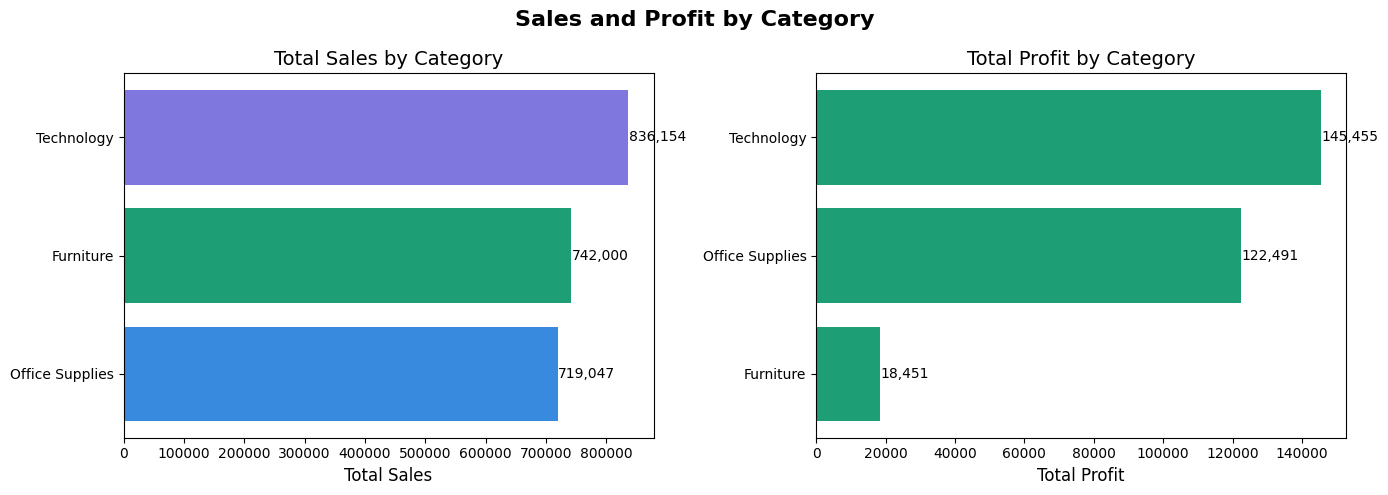


Profit Margin by Category:
  Furniture: 2.5%
  Office Supplies: 17.0%
  Technology: 17.4%


In [7]:
# Analysis 1: Sales and Profit by Catagory

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales and Profit by Category', fontsize=16, fontweight='bold')

# Total Sales by Category
sales_cat = df.groupby('Category')['Sales'].sum().sort_values()
color_sales = ['#378ADD', '#1D9E75', '#7F77DD']
axes[0].barh(sales_cat.index, sales_cat.values, color=color_sales)
axes[0].set_title('Total Sales by Category', fontsize=14)
axes[0].set_xlabel('Total Sales', fontsize=12)
for i, v in enumerate(sales_cat.values):
    axes[0].text(v + 500, i, f'{v:,.0f}', va='center', fontsize=10)

# Total Profit by Category
profit_cat = df.groupby('Category')['Profit'].sum().sort_values()
colors_profit = ['#E24B4A' if v < 0 else '#1D9E75' for v in profit_cat.values]    
axes[1].barh(profit_cat.index, profit_cat.values, color=colors_profit)
axes[1].set_title('Total Profit by Category', fontsize=14)
axes[1].set_xlabel('Total Profit', fontsize=12)
for i, v in enumerate(profit_cat.values):
    axes[1].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/sales_profit_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Profit Margin by Category
print("\nProfit Margin by Category:")
for cat in df['Category'].unique():
    subset = df[df['Category'] == cat]
    margin = subset['Profit'].sum() / subset['Sales'].sum() * 100
    print(f"  {cat}: {margin:.1f}%")
    

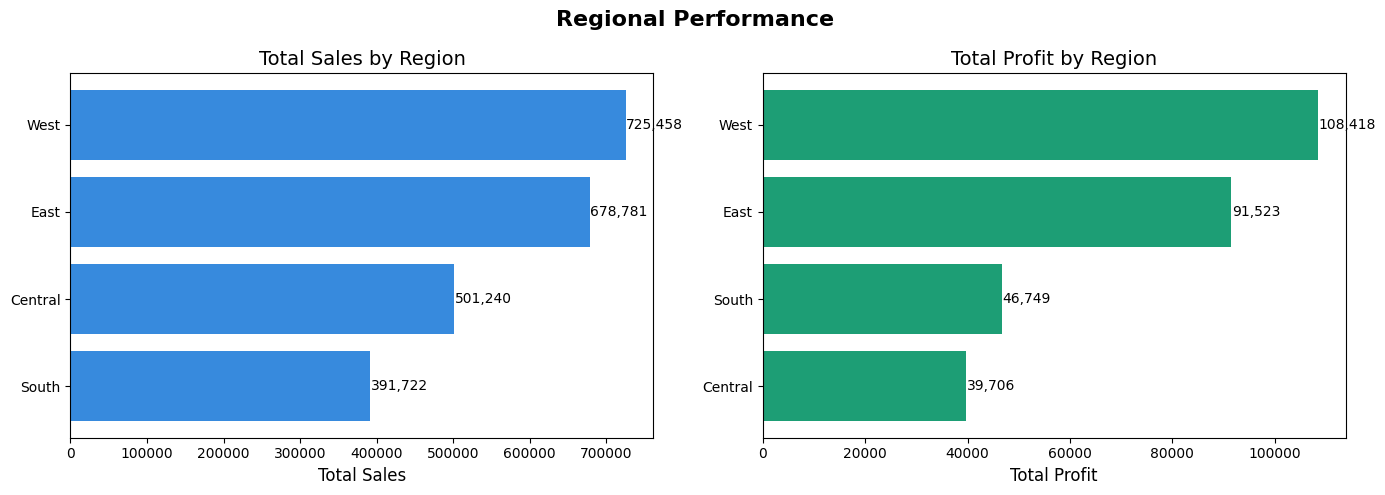


Profit Margin by Region:
  South: 11.9%
  West: 14.9%
  Central: 7.9%
  East: 13.5%


In [8]:
# Analysis 2: Performance by Region

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regional Performance', fontsize=16, fontweight='bold')

# Sales by Region
sales_region = df.groupby('Region')['Sales'].sum().sort_values()
axes[0].barh(sales_region.index, sales_region.values, color='#378ADD')
axes[0].set_title('Total Sales by Region', fontsize=14)
axes[0].set_xlabel('Total Sales', fontsize=12)
for i, v in enumerate(sales_region.values):
    axes[0].text(v + 500, i, f'{v:,.0f}', va='center', fontsize=10)

# Profit by Region
profit_region = df.groupby('Region')['Profit'].sum().sort_values()
colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in profit_region.values]
axes[1].barh(profit_region.index, profit_region.values, color=colors)
axes[1].set_title('Total Profit by Region', fontsize=14)
axes[1].set_xlabel('Total Profit', fontsize=12)
for i, v in enumerate(profit_region.values):
    axes[1].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/sales_profit_by_region.png', dpi=150, bbox_inches='tight')
plt.show()        

# Profit Margin by Region
print("\nProfit Margin by Region:")
for region in df['Region'].unique():
    subset = df[df['Region'] == region]
    margin = subset['Profit'].sum() / subset['Sales'].sum() * 100
    print(f"  {region}: {margin:.1f}%")
    

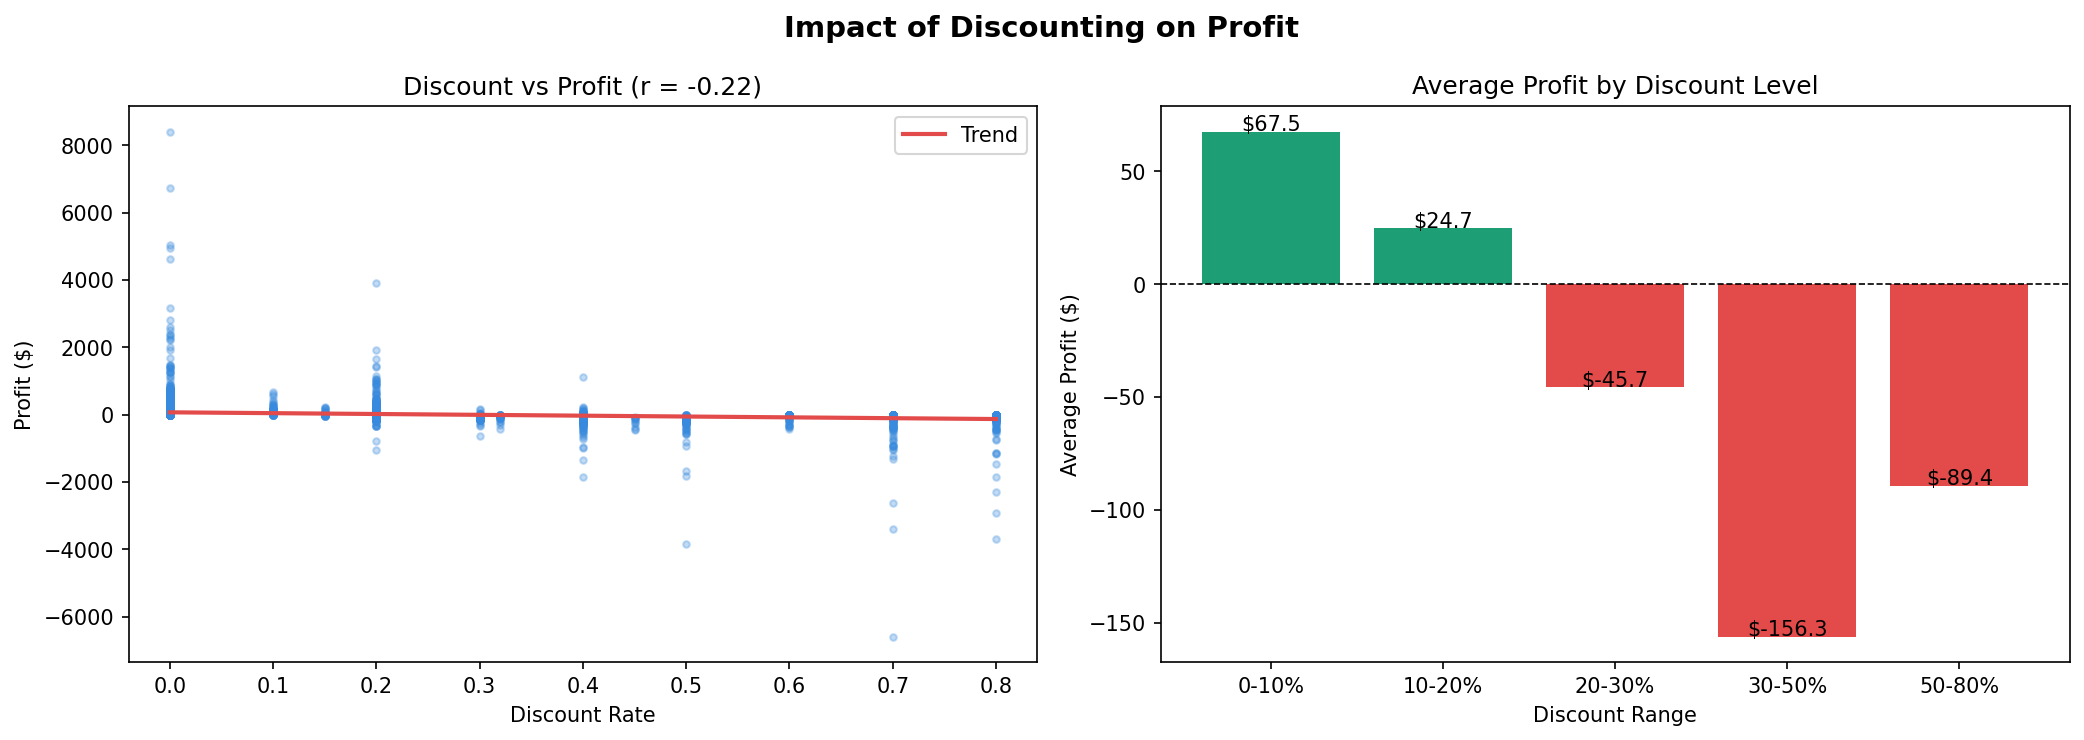

In [36]:
# ── Analysis 3: Discount vs Profit ────────────────────────

# Calculate correlation first
corr = df['Discount'].corr(df['Profit'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact of Discounting on Profit', fontsize=14, fontweight='bold')

# Scatter plot
axes[0].scatter(df['Discount'], df['Profit'], 
                alpha=0.3, color='#378ADD', s=10)
z = np.polyfit(df['Discount'], df['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['Discount'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#E24B4A', linewidth=2, label='Trend')
axes[0].set_title(f'Discount vs Profit (r = {corr:.2f})')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')
axes[0].legend()

# Average profit by discount bucket
df['Discount Bucket'] = pd.cut(df['Discount'], 
                                bins=[0, 0.1, 0.2, 0.3, 0.5, 0.8],
                                labels=['0-10%','10-20%','20-30%','30-50%','50-80%'],
                                include_lowest=True)
avg_profit = df.groupby('Discount Bucket', observed=True)['Profit'].mean()
colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in avg_profit.values]
axes[1].bar(avg_profit.index, avg_profit.values, color=colors)
axes[1].set_title('Average Profit by Discount Level')
axes[1].set_xlabel('Discount Range')
axes[1].set_ylabel('Average Profit ($)')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(avg_profit.values):
    axes[1].text(i, v + 0.5, f'${v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image
Image('../images/discount_vs_profit.png')

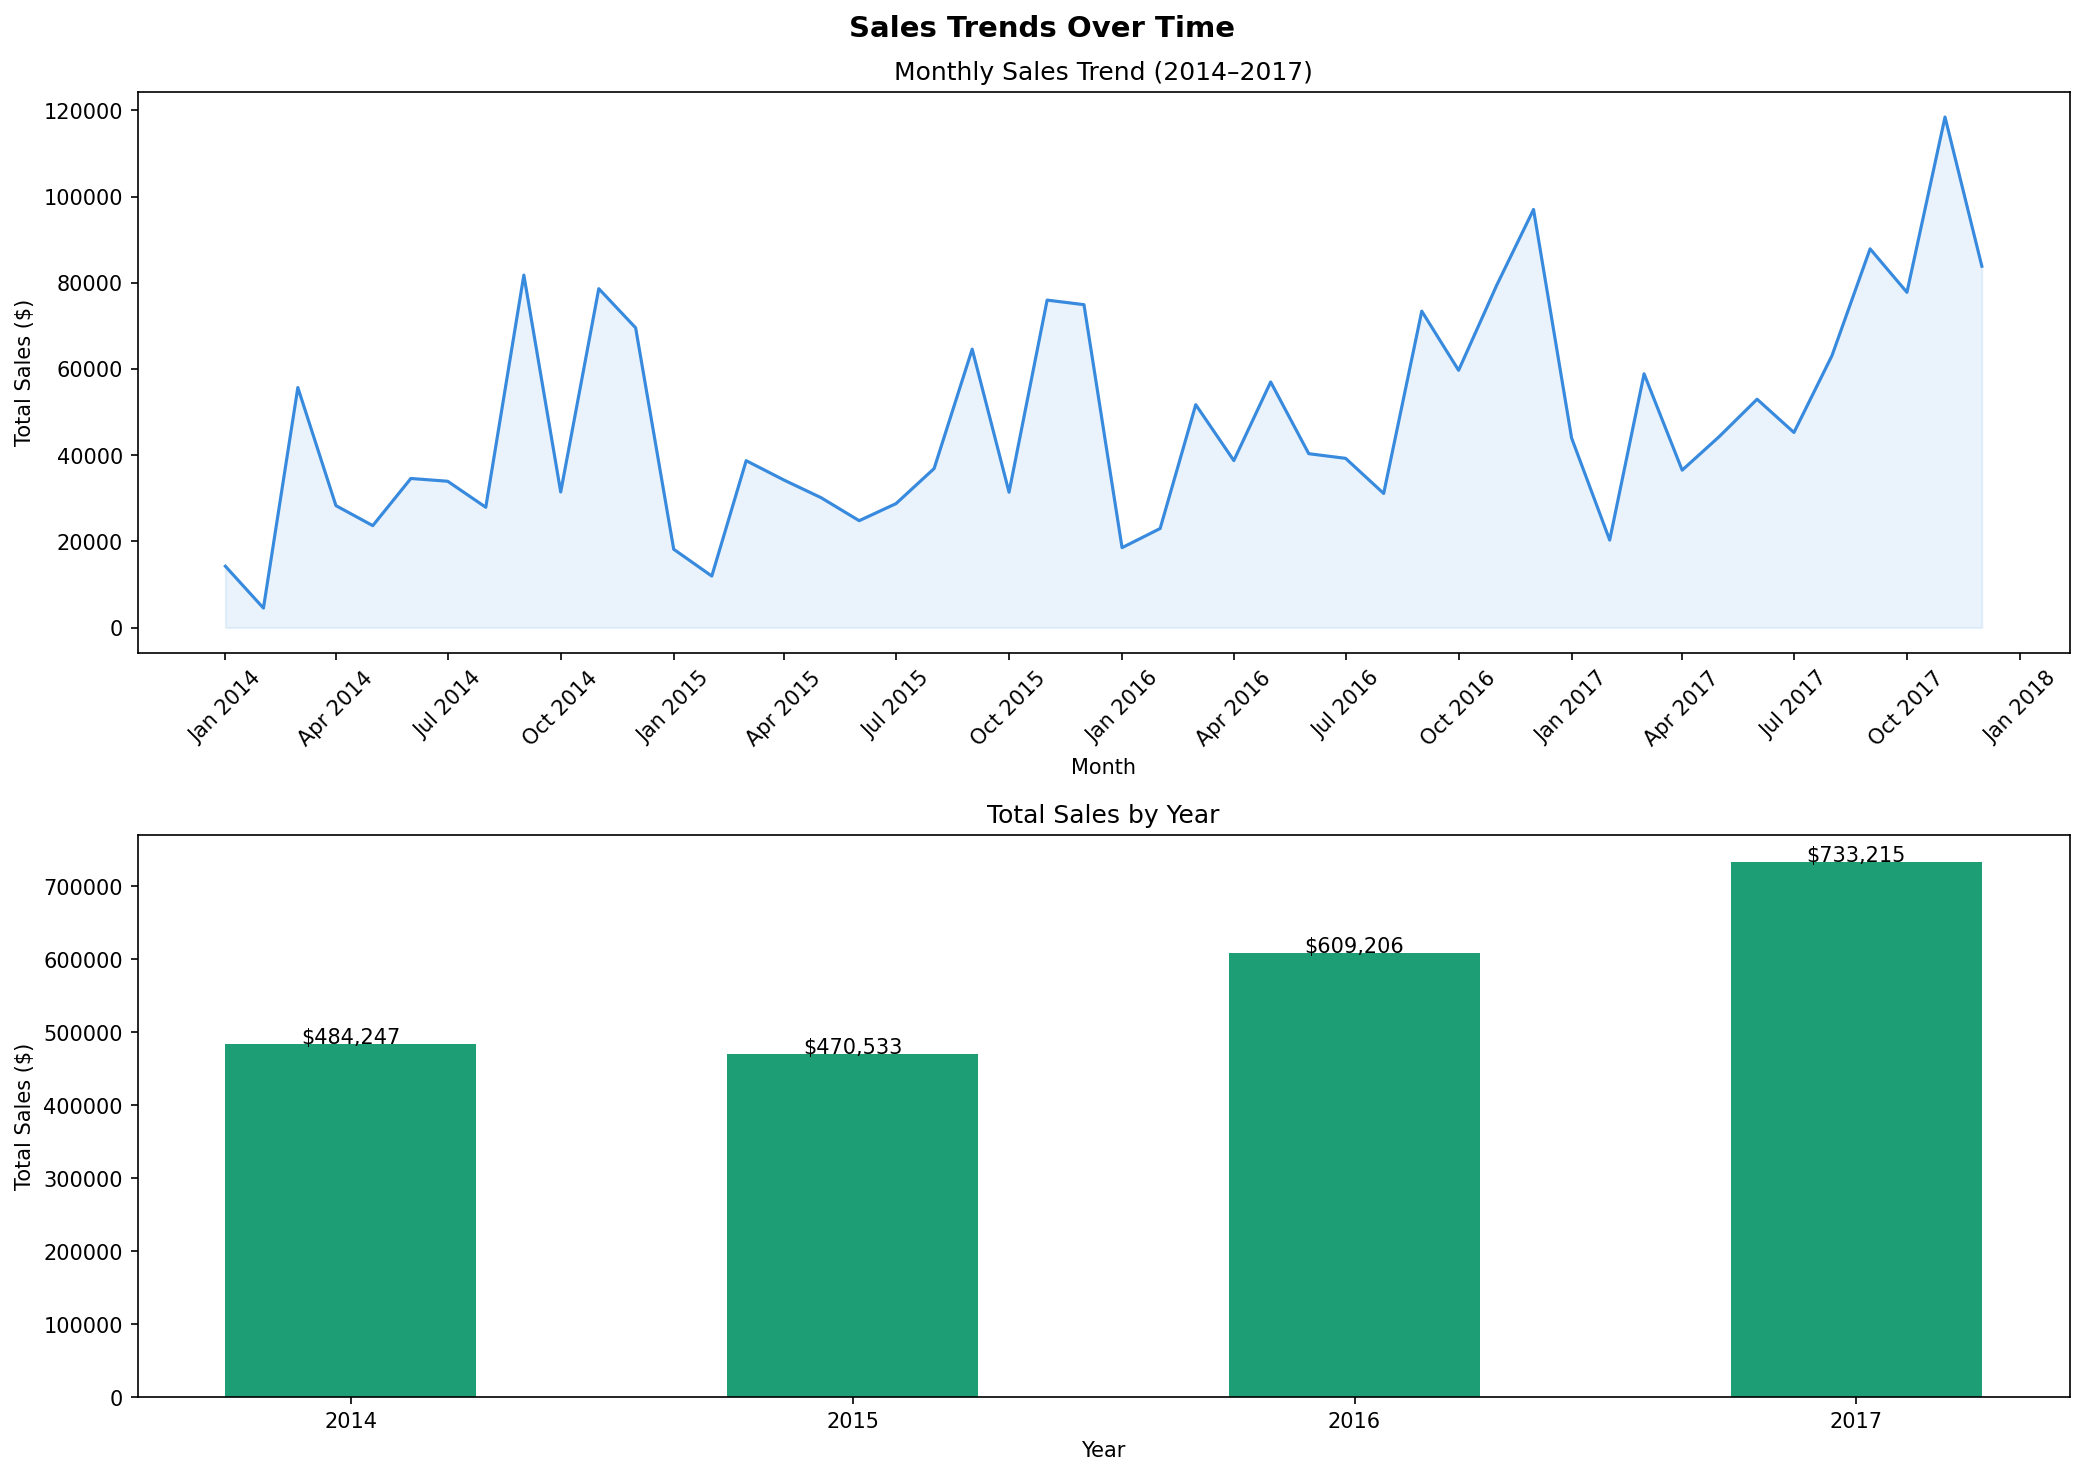

In [37]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Sales Trends Over Time', fontsize=14, fontweight='bold')

# Monthly sales line chart
axes[0].plot(monthly['YearMonth'], monthly['Sales'], color='#378ADD', linewidth=1.5)
axes[0].fill_between(monthly['YearMonth'], monthly['Sales'], alpha=0.1, color='#378ADD')
axes[0].set_title('Monthly Sales Trend (2014–2017)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales ($)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].tick_params(axis='x', rotation=45)

# Yearly bar chart
yearly = df.groupby('Year')['Sales'].sum().reset_index()
axes[1].bar(yearly['Year'].astype(str), yearly['Sales'], color='#1D9E75', width=0.5)
axes[1].set_title('Total Sales by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Sales ($)')
for i, row in yearly.iterrows():
    axes[1].text(i, row['Sales'] + 500, f'${row["Sales"]:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/sales_trend.png', dpi=150, bbox_inches='tight')
plt.close()

# Now display the saved image
from IPython.display import Image
Image('../images/sales_trend.png')




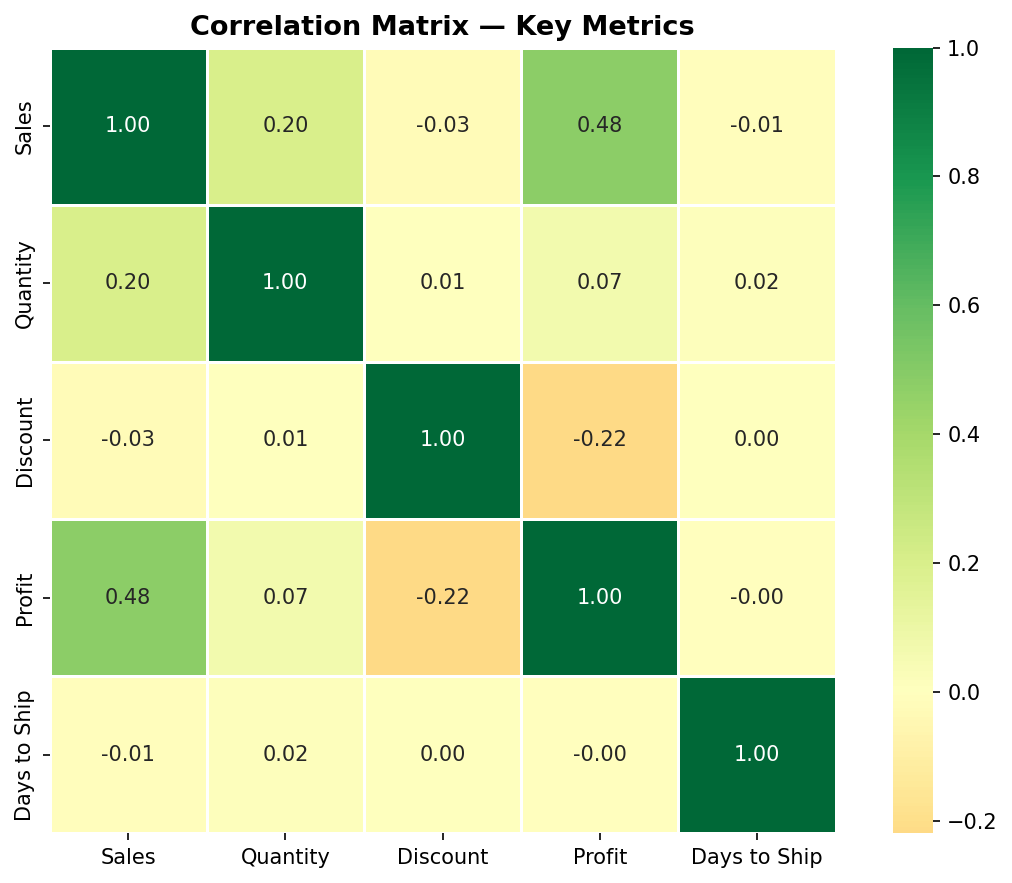

In [38]:
# Analysis 5: Correlation Heatmap


numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Days to Ship']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.5,
            ax=ax)
ax.set_title('Correlation Matrix — Key Metrics', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image
Image('../images/correlation_heatmap.png')

In [39]:
# Recreate Days to Ship column
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Confirm it's there
print(df['Days to Ship'].head())

0    3
1    3
2    4
3    7
4    7
Name: Days to Ship, dtype: int64


Profit Margin by Segment:
  Consumer: 11.5%
  Corporate: 13.0%
  Home Office: 14.0%


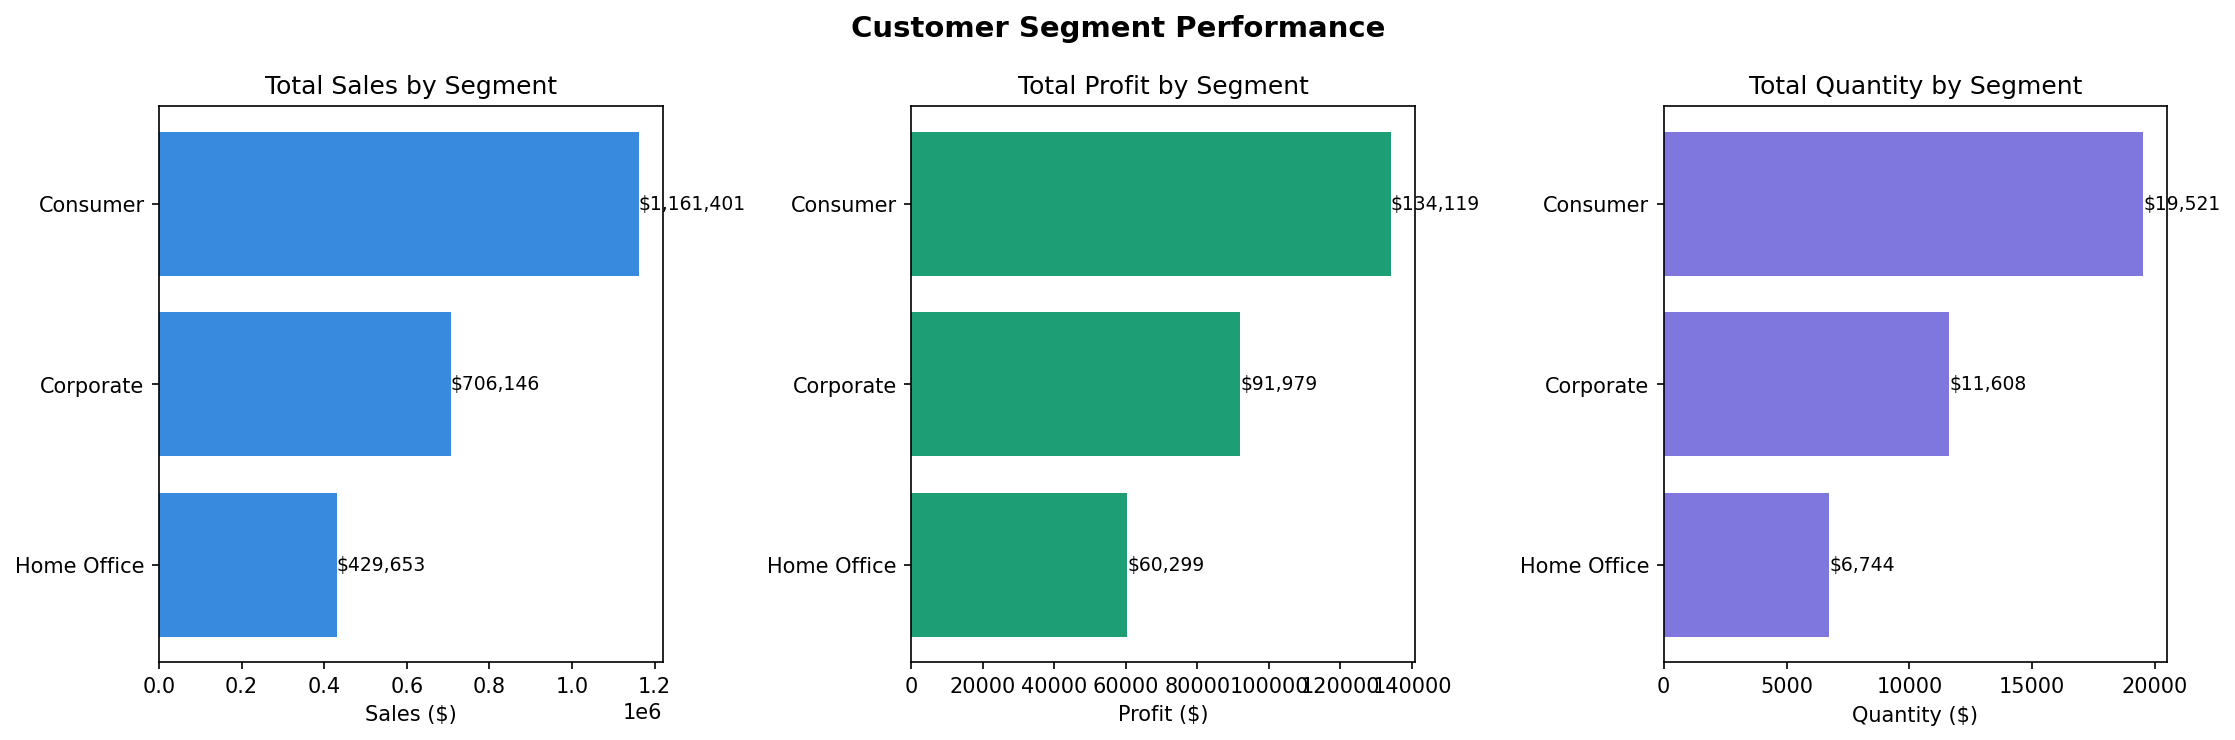

In [40]:
# Analysis 6: Customer Segment Performance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Segment Performance', fontsize=14, fontweight='bold')

metrics = ['Sales', 'Profit', 'Quantity']
colors = ['#378ADD', '#1D9E75', '#7F77DD']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    seg_data = df.groupby('Segment')[metric].sum().sort_values()
    axes[i].barh(seg_data.index, seg_data.values, color=color)
    axes[i].set_title(f'Total {metric} by Segment')
    axes[i].set_xlabel(f'{metric} ($)')
    for j, v in enumerate(seg_data.values):
        axes[i].text(v + 10, j, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/segment_performance.png', dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image

# Profit margin per segment
print("Profit Margin by Segment:")
for seg in df['Segment'].unique():
    subset = df[df['Segment'] == seg]
    margin = (subset['Profit'].sum() / subset['Sales'].sum()) * 100
    print(f"  {seg}: {margin:.1f}%")

Image('../images/segment_performance.png')

Loss-Making Sub-Categories:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


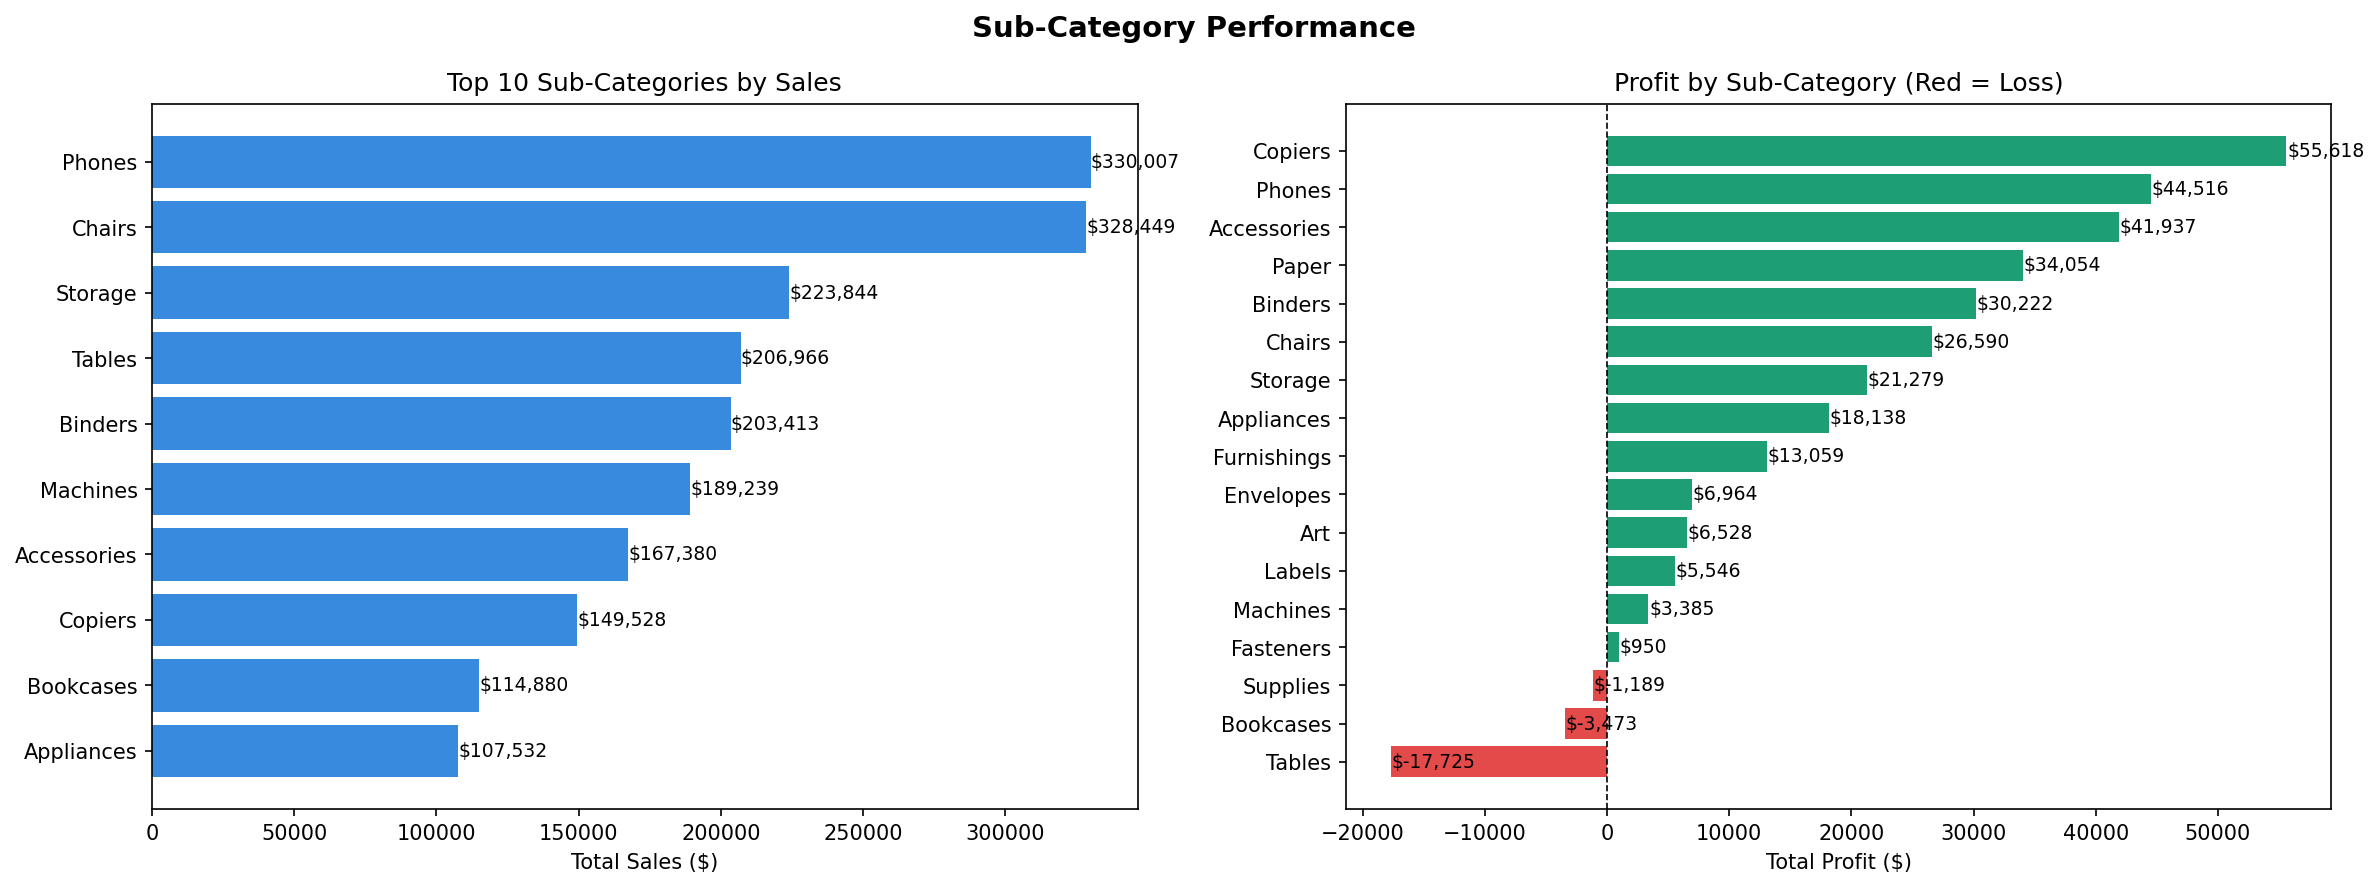

In [41]:
# Analysis 7: Sub-Category Deep Dive 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sub-Category Performance', fontsize=14, fontweight='bold')

# Top 10 by Sales
top_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values().tail(10)
axes[0].barh(top_sales.index, top_sales.values, color='#378ADD')
axes[0].set_title('Top 10 Sub-Categories by Sales')
axes[0].set_xlabel('Total Sales ($)')
for i, v in enumerate(top_sales.values):
    axes[0].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)

# Profit by Sub-Category (all)
profit_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in profit_sub.values]
axes[1].barh(profit_sub.index, profit_sub.values, color=colors)
axes[1].set_title('Profit by Sub-Category (Red = Loss)')
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(profit_sub.values):
    axes[1].text(v + 50, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/subcategory_performance.png', dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image

# Loss making sub-categories
print("Loss-Making Sub-Categories:")
losses = df.groupby('Sub-Category')['Profit'].sum()
print(losses[losses < 0].sort_values())

Image('../images/subcategory_performance.png')

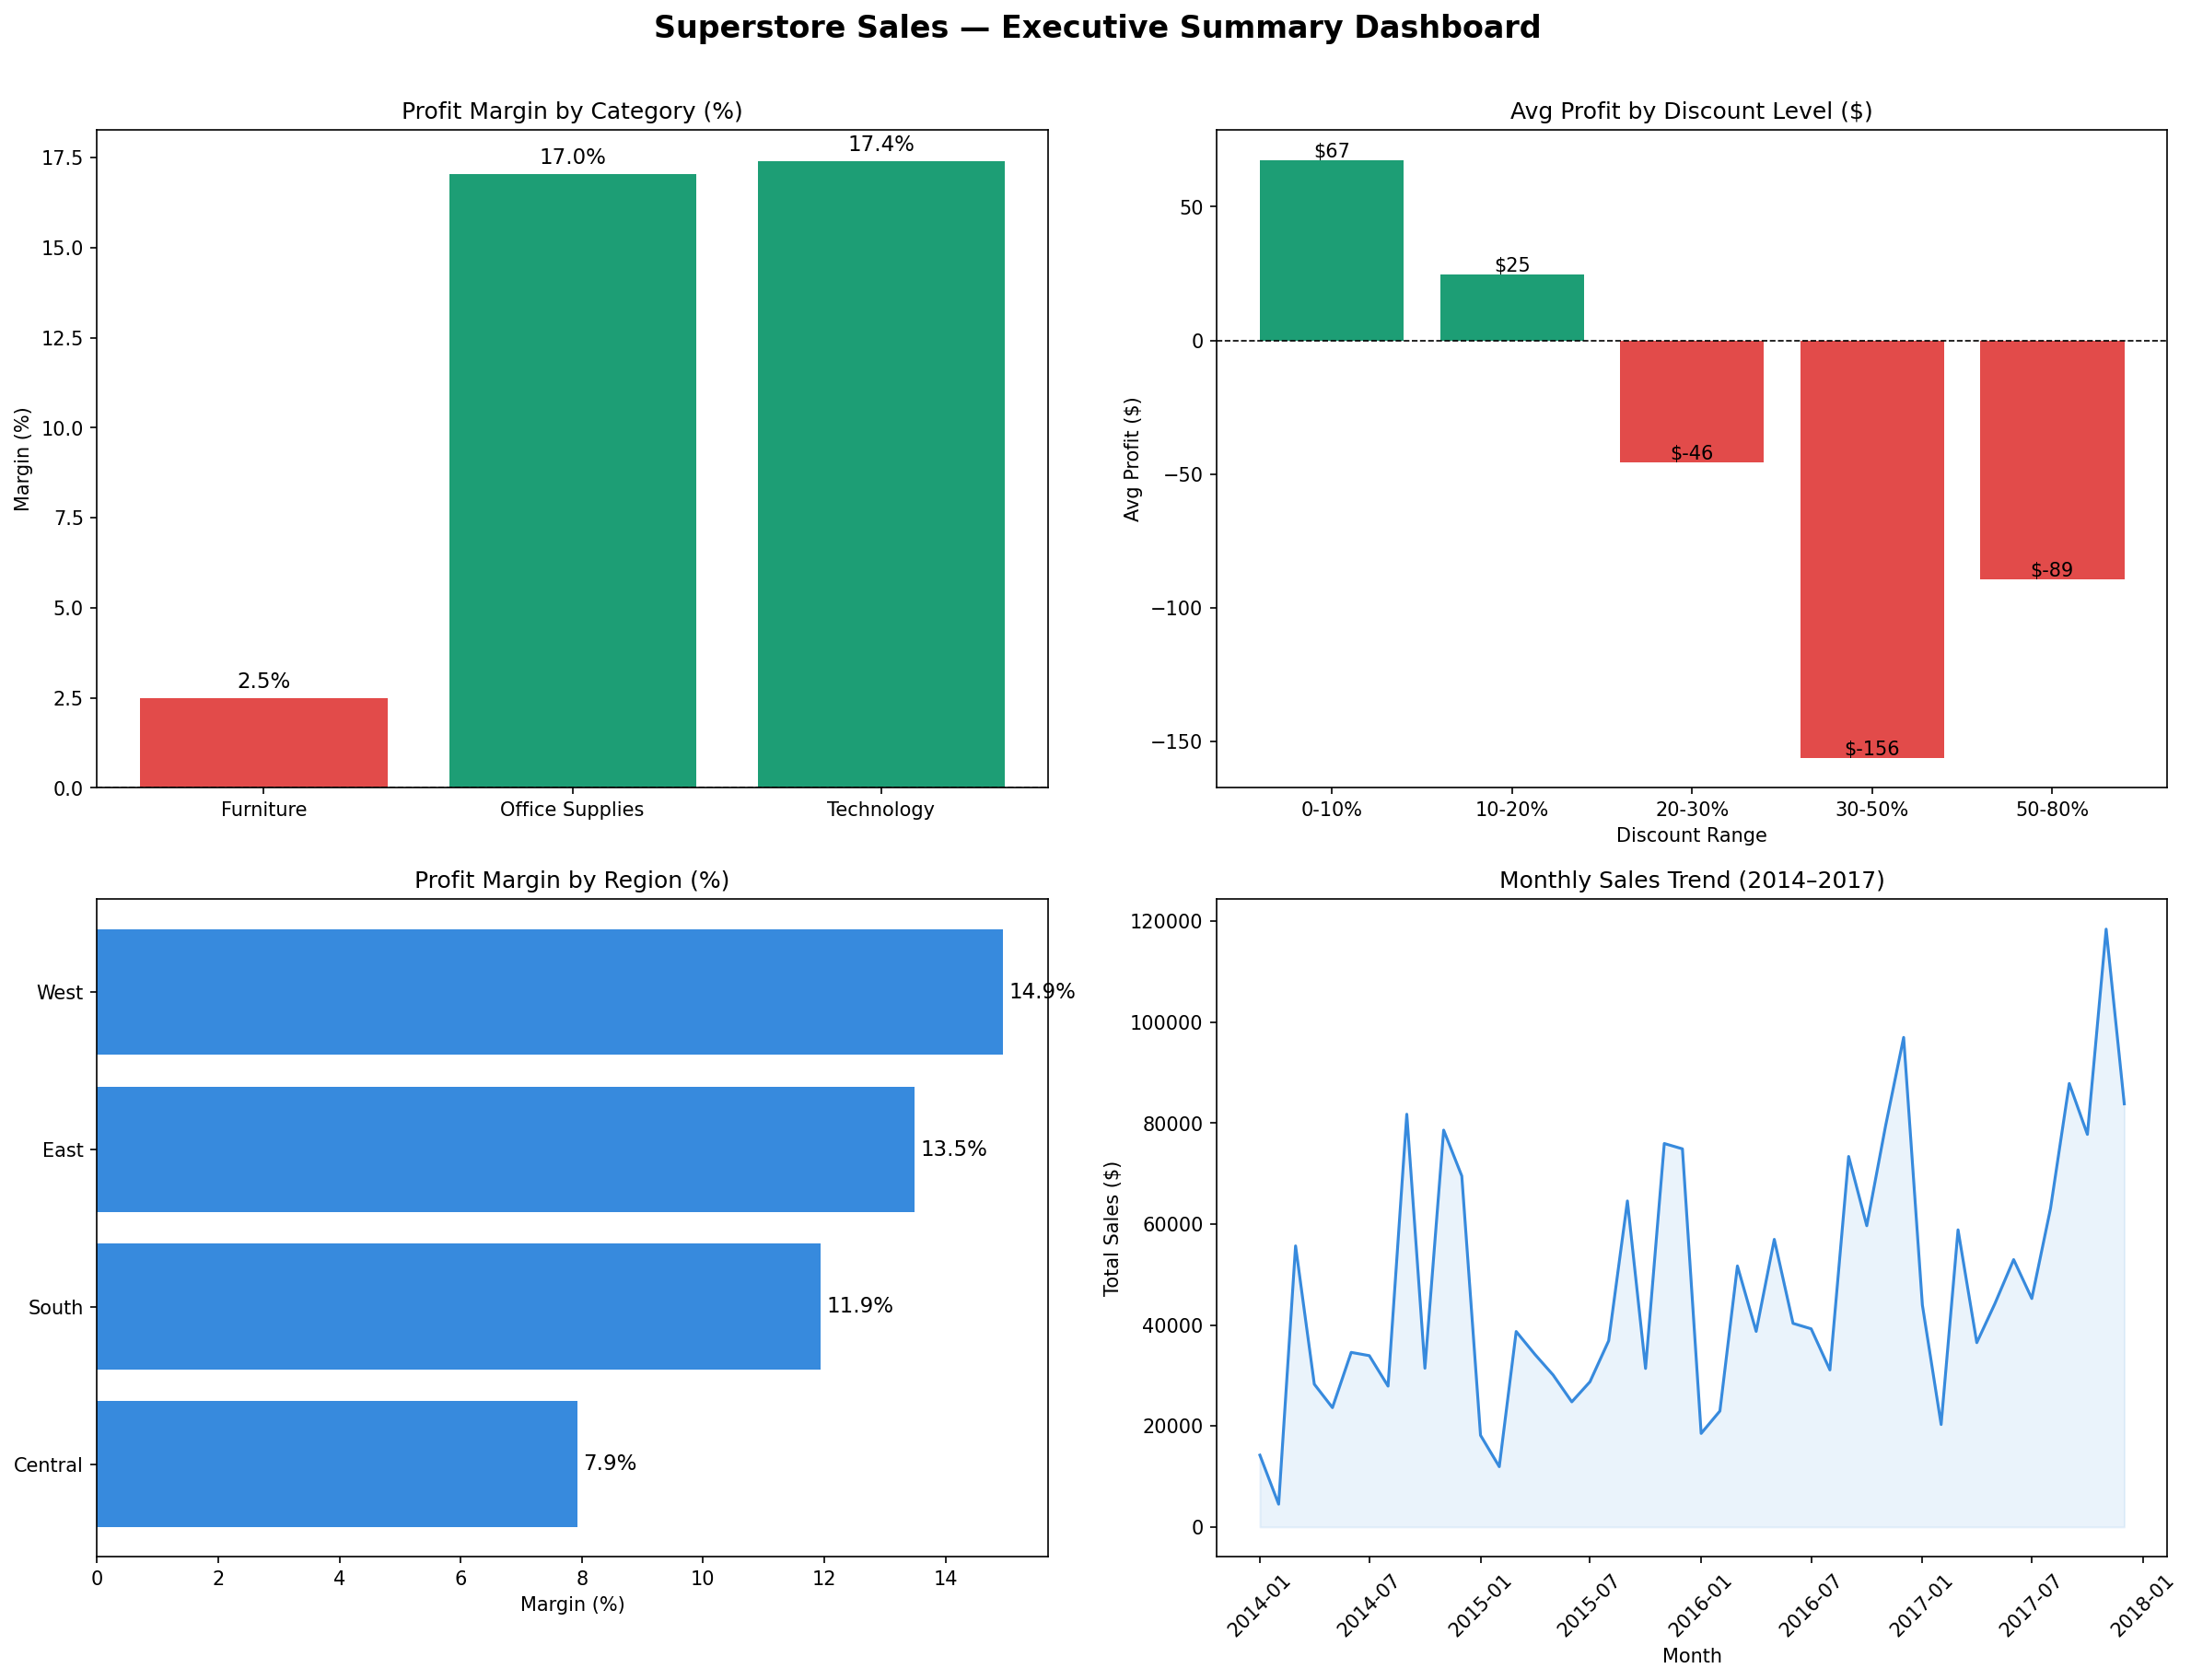

In [42]:
# Analysis 8: Summary Dashboard 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Superstore Sales — Executive Summary Dashboard', 
             fontsize=16, fontweight='bold', y=1.01)

# 1. Profit Margin by Category
margins_cat = {}
for cat in df['Category'].unique():
    subset = df[df['Category'] == cat]
    margins_cat[cat] = (subset['Profit'].sum() / subset['Sales'].sum()) * 100
margins_cat = pd.Series(margins_cat).sort_values()
colors = ['#E24B4A' if v < 5 else '#1D9E75' for v in margins_cat.values]
axes[0,0].bar(margins_cat.index, margins_cat.values, color=colors)
axes[0,0].set_title('Profit Margin by Category (%)')
axes[0,0].set_ylabel('Margin (%)')
axes[0,0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(margins_cat.values):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

# 2. Average Profit by Discount Bucket
avg_profit = df.groupby('Discount Bucket', observed=True)['Profit'].mean()
colors2 = ['#1D9E75' if v > 0 else '#E24B4A' for v in avg_profit.values]
axes[0,1].bar(avg_profit.index, avg_profit.values, color=colors2)
axes[0,1].set_title('Avg Profit by Discount Level ($)')
axes[0,1].set_xlabel('Discount Range')
axes[0,1].set_ylabel('Avg Profit ($)')
axes[0,1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(avg_profit.values):
    axes[0,1].text(i, v + 1, f'${v:.0f}', ha='center', fontsize=10)

# 3. Profit Margin by Region
margins_reg = {}
for reg in df['Region'].unique():
    subset = df[df['Region'] == reg]
    margins_reg[reg] = (subset['Profit'].sum() / subset['Sales'].sum()) * 100
margins_reg = pd.Series(margins_reg).sort_values()
axes[1,0].barh(margins_reg.index, margins_reg.values, color='#378ADD')
axes[1,0].set_title('Profit Margin by Region (%)')
axes[1,0].set_xlabel('Margin (%)')
for i, v in enumerate(margins_reg.values):
    axes[1,0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=11)

# 4. Monthly Sales Trend
axes[1,1].plot(monthly['YearMonth'], monthly['Sales'], color='#378ADD', linewidth=1.5)
axes[1,1].fill_between(monthly['YearMonth'], monthly['Sales'], alpha=0.1, color='#378ADD')
axes[1,1].set_title('Monthly Sales Trend (2014–2017)')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Total Sales ($)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../images/executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.close()

from IPython.display import Image
Image('../images/executive_dashboard.png')